# Import Packages

In [32]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import os 
from glob import glob

In [ ]:
# Configure matplotlib visualization parameters for consistency across all plots
plt.rcParams['font.size'] = 14  # Base font size
plt.rcParams['axes.labelsize'] = 14  # Axis label font size
plt.rcParams['axes.titlesize'] = 14  # Plot title font size
plt.rcParams['xtick.labelsize'] = 14  # X-axis tick label size
plt.rcParams['ytick.labelsize'] = 14  # Y-axis tick label size
plt.rcParams['legend.fontsize'] = 14  # Legend font size

# work directory

In [33]:
wrk_directory ="C:/Users/l_v_v/Documents/GitHub/time_series_curuai/datasets/Parameters Time series/TSS Modeling"

# import Data

In [40]:
paths = sorted(glob(os.path.join(wrk_directory,"*cv*.csv")))

cv_dfs = []

for cv_metric in paths:
    df_cv = pd.read_csv(cv_metric)
    df_cv['rmse'] = np.sqrt(df_cv['mse'])
    df_cv['rmse_std'] = np.sqrt(df_cv['mse_std'])
    if 'Unnamed: 0' in df_cv.columns:
        df_cv = df_cv.drop(columns=['Unnamed: 0'])
    
    cv_dfs.append(df_cv)

final_cv_df = pd.concat(cv_dfs, ignore_index=True)


In [41]:
# Identify unique model runs (excluding floating point metric columns to avoid duplication)
subset_cols = ['Model', 'Group', 'Feature']
if 'Params' in final_cv_df.columns:
    subset_cols.append('Params')
if 'water_period' in final_cv_df.columns:
    subset_cols.append('water_period')

# Drop duplicates
final_cv_df = final_cv_df.drop_duplicates(subset=subset_cols, keep='first')

cv_df = final_cv_df.loc[final_cv_df['water_period'].isna()].copy()

In [42]:
period_cv = final_cv_df.dropna(subset='water_period')
period_cv

,Model,Group,Feature,Params,r2,mae,mse,mape,exp_var,r2_std,mae_std,mse_std,mape_std,exp_var_std,rmse,rmse_std,water_period
63,ols,single_band,nir,NaN,0.750459,13.136463,4.484970e+02,0.286021,0.403573,1.132934,5.760059,4.600217e+02,0.087980,0.652726,21.177748,21.448116,R
64,ols,single_band,red,NaN,0.468110,11.932755,4.286936e+02,0.256130,0.315162,0.553012,5.948506,4.663569e+02,0.106278,0.405612,20.704917,21.595297,R
65,ols,single_band,nir_red_ratio,NaN,0.908369,13.853791,5.581768e+02,0.347170,0.400018,1.234857,6.622743,5.320955e+02,0.173838,0.813981,23.625766,23.067196,R
66,ols,single_band,red_nir_ratio,NaN,0.542325,13.245558,4.979487e+02,0.309173,0.088449,0.473377,6.405950,5.129363e+02,0.133744,0.140359,22.314763,22.648097,R
67,ols,multi_band,nir_red,NaN,0.688434,12.612278,4.277580e+02,0.267919,0.464074,1.072256,5.507978,4.434552e+02,0.085684,0.645476,20.682311,21.058376,R
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,polynomial3,multi_band,nir_red_green,NaN,0.317686,66.027041,7.853916e+03,0.536376,0.343744,0.383498,18.759147,4.361434e+03,0.201583,0.400081,88.622324,66.041155,LW
299,polynomial3,multi_band,all_bands,NaN,99.808216,285.634545,8.580621e+05,4.007965,88.781248,221.644278,264.804219,2.115743e+06,4.208508,196.773421,926.316436,1454.559315,LW
300,polynomial3,multi_band,location,NaN,548.006135,885.275181,3.527449e+06,9.384928,493.743663,624.511763,590.640282,5.073580e+06,7.745350,575.009597,1878.150381,2252.460984,LW
301,polynomial3,multi_band,period,NaN,99.808216,285.634545,8.580621e+05,4.007965,88.781248,221.644277,264.804219,2.115743e+06,4.208508,196.773420,926.316436,1454.559315,LW


# Sorting Model Metrics

In [43]:
import pandas as pd
import numpy as np

def sort_models_weight(df, top_n=25, stability_weight=0.2):
    """
    Rank models based on best metric performance AND stability (low standard deviation).
    
    Composite Score = (Performance_Score * (1 - stability_weight)) + (Stability_Score * stability_weight)
    
    Performance Weights (within the performance component):
    - r2: 0.3
    - Inverse MAE: 0.3
    - Inverse RMSE: 0.2
    - MAPE: 0.2
    
    Stability:
    - Calculates the average normalized score of all available `_std` columns (r2_std, mae_std, etc.).
    - Lower standard deviation contributes to a higher stability score.
    
    Args:
        df: DataFrame with model metrics (expects 'r2', 'mae' etc. AND 'r2_std', 'mae_std' etc.)
        top_n: Return top N models (default 25)
        stability_weight: How much the standard deviation influences the final rank (0.0 to 1.0)
    
    Returns:
        DataFrame with models ranked by risk-adjusted composite score.
    """
    df = df.copy()
    
    # --- 1. Filter Invalid Models ---
    initial_count = len(df)
    mask = pd.Series([True] * len(df), index=df.index)
    
    if 'r2' in df.columns:
        mask &= (df['r2'] > 0.55) & (df['r2'] <= 1.1)
    if 'mape' in df.columns:
        mask &= (df['mape'] <= 0.7)
        
    df = df[mask].reset_index(drop=True)
    
    dropped_count = initial_count - len(df)
    if dropped_count > 0:
        print(f"Dropped {dropped_count} rows based on quality thresholds")
    if len(df) == 0:
        print("Warning: No rows remain after filtering!")
        return df

    # --- 2. Calculate Performance Score (The "Accuracy" part) ---
    # We calculate this separately first so we can blend it with stability later
    df['perf_score'] = 0.0
    
    # R2: Higher is better
    if 'r2' in df.columns:
        r2_range = df['r2'].max() - df['r2'].min()
        if r2_range == 0: r2_range = 1.0 # Avoid div/0
        r2_norm = (df['r2'] - df['r2'].min()) / r2_range
        df['perf_score'] += r2_norm * 0.3

    # MAE: Lower is better (Inverse)
    if 'mae' in df.columns:
        mae_inv = 1.0 / (df['mae'] + 1e-8)
        mae_range = mae_inv.max() - mae_inv.min()
        if mae_range == 0: mae_range = 1.0
        mae_norm = (mae_inv - mae_inv.min()) / mae_range
        df['perf_score'] += mae_norm * 0.3

    # RMSE: Lower is better (Inverse)
    if 'rmse' in df.columns:
        rmse_inv = 1.0 / (df['rmse'] + 1e-8)
        rmse_range = rmse_inv.max() - rmse_inv.min()
        if rmse_range == 0: rmse_range = 1.0
        rmse_norm = (rmse_inv - rmse_inv.min()) / rmse_range
        df['perf_score'] += rmse_norm * 0.2

    # MAPE: Lower is better (Inverse)
    if 'mape' in df.columns:
        mape_inv = 1.0 / (df['mape'] + 1e-8)
        mape_range = mape_inv.max() - mape_inv.min()
        if mape_range == 0: mape_range = 1.0
        mape_norm = (mape_inv - mape_inv.min()) / mape_range
        df['perf_score'] += mape_norm * 0.2

    # --- 3. Calculate Stability Score (The "Standard Deviation" part) ---
    # This score is 1.0 if the model has the lowest standard deviation, 0.0 if highest.
    df['stab_score'] = 0.0
    std_metrics_count = 0
    
    # List of std columns to look for
    possible_std_cols = ['r2_std', 'mae_std', 'rmse_std', 'mape_std']
    
    for std_col in possible_std_cols:
        if std_col in df.columns:
            # We want LOW std deviation, so we invert the normalization:
            # Score = (Max_Std - Current_Std) / (Max_Std - Min_Std)
            s_min = df[std_col].min()
            s_max = df[std_col].max()
            s_range = s_max - s_min
            
            if s_range > 1e-8:
                # Normal case: Scale 0 to 1 (1 being best/lowest std)
                df[f'{std_col}_norm'] = (s_max - df[std_col]) / s_range
            else:
                # If all models have same std, give everyone 1.0
                df[f'{std_col}_norm'] = 1.0
            
            df['stab_score'] += df[f'{std_col}_norm']
            std_metrics_count += 1
            
    # Average the stability score across available metrics
    if std_metrics_count > 0:
        df['stab_score'] /= std_metrics_count
    else:
        # If no std columns exist, neutral score
        df['stab_score'] = 0.5 

    # --- 4. Final Composite Score ---
    # Combine Performance (e.g., 80%) and Stability (e.g., 20%)
    perf_weight = 1.0 - stability_weight
    df['composite_score'] = (df['perf_score'] * perf_weight) + (df['stab_score'] * stability_weight)

    # --- 5. Sorting and Tiebreakers ---
    sort_cols = ['composite_score']
    ascending = [False] # Descending score

    # Tiebreaker 1: Stability Score (Higher is better)
    sort_cols.append('stab_score')
    ascending.append(False)

    # Tiebreaker 2: R2 (Higher is better)
    if 'r2' in df.columns:
        sort_cols.append('r2')
        ascending.append(False)
        
    # Tiebreaker 3: MAE (Lower is better)
    if 'mae' in df.columns:
        sort_cols.append('mae')
        ascending.append(True)

    # Final Tiebreaker: Index
    df['_row_index'] = range(len(df))
    sort_cols.append('_row_index')
    ascending.append(True)

    df_sorted = df.sort_values(by=sort_cols, ascending=ascending).reset_index(drop=True)
    
    # Cleanup helper columns
    cols_to_drop = ['_row_index'] + [c for c in df.columns if c.endswith('_norm')]
    df_sorted = df_sorted.drop(columns=cols_to_drop, errors='ignore')

    return df_sorted.head(top_n)

In [44]:
# Assuming cv_df has 'r2', 'r2_std', 'mae', 'mae_std', etc.
best_models = sort_models_weight(
    cv_df.loc[~cv_df['Feature'].isin(['location','period','period_location'])], 
    top_n=5,
    stability_weight=0.15 # Give 15% priority to stability
)

print(best_models[['Model', 'composite_score', 'perf_score', 'stab_score', 'r2', 'r2_std', 'mae', 'mae_std']])

Dropped 17 rows based on quality thresholds
         Model  composite_score  perf_score  stab_score        r2    r2_std  \
0          KRR         0.838853    0.841567    0.823472  0.697487  0.111018   
1  polynomial2         0.815267    0.817527    0.802460  0.691890  0.114191   
2           RF         0.794662    0.795430    0.790315  0.689028  0.092500   
3      GBR_GEE         0.768639    0.793988    0.624996  0.747965  0.064622   
4          GBR         0.726499    0.724856    0.735806  0.651853  0.147636   

         mae   mae_std  
0  20.376511  4.414850  
1  20.426360  4.461346  
2  20.131791  4.640936  
3  20.552997  5.114121  
4  20.521773  4.561881  


In [45]:
best_models.head()

,Model,Group,Feature,Params,r2,mae,mse,mape,exp_var,r2_std,mae_std,mse_std,mape_std,exp_var_std,rmse,rmse_std,water_period,perf_score,stab_score,composite_score
0,KRR,multi_band,nir_red,"{'alpha': 0.001, 'degree': 2, 'gamma': 100.0, ...",0.697487,20.376511,1132.009309,0.424498,0.705410,0.111018,4.414850,554.563961,0.070104,0.110221,33.645346,23.549182,NaN,0.841567,0.823472,0.838853
1,polynomial2,multi_band,nir_red,NaN,0.691890,20.426360,1162.209301,0.421390,0.700224,0.114191,4.461346,592.693660,0.066333,0.113497,34.091191,24.345301,NaN,0.817527,0.802460,0.815267
2,RF,multi_band,all_bands,"{'criterion': 'absolute_error', 'max_depth': 5...",0.689028,20.131791,1240.570867,0.427213,0.695339,0.092500,4.640936,615.931085,0.067505,0.094620,35.221739,24.817959,NaN,0.795430,0.790315,0.794662
3,GBR_GEE,multi_band,all_bands,"{'numberOfTrees': 500, 'shrinkage': None, 'sam...",0.747965,20.552997,1366.385191,0.456640,0.756923,0.064622,5.114121,842.256605,0.095316,0.063860,36.964648,29.021658,NaN,0.793988,0.624996,0.768639
4,GBR,multi_band,nir_red_green,"{'learning_rate': 0.1, 'loss': 'absolute_error...",0.651853,20.521773,1307.778076,0.380725,0.669521,0.147636,4.561881,671.228654,0.054488,0.130381,36.163214,25.908081,NaN,0.724856,0.735806,0.726499


In [46]:
import pandas as pd
import numpy as np

def sort_models_count(df, top_n=25):
    """
    Rank models based on a 'Win Count' system that rewards both 
    Performance and Stability.
    
    Score = (Performance Wins) + (Stability Wins)
    
    Performance Wins:
        - Best value for r2, mae, rmse, etc.
    
    Stability Wins (New Criteria):
        - Lowest standard deviation for r2_std, mae_std, etc.
        - A model 'wins' if it is the most stable for that metric.
            
    Sorting Order:
    1. Total Wins (Descending)
    2. R2 (Descending) - Tiebreaker 1 (Performance)
    3. MAE (Ascending) - Tiebreaker 2 (Error)
    
    Args:
        df: DataFrame with model metrics (e.g. 'r2', 'r2_std')
        top_n: Return top N models (default 25)
    
    Returns:
        DataFrame with models ranked by total win count.
    """
    df = df.copy()
    
    # --- 1. Apply Quality Filters ---
    initial_count = len(df)
    mask = pd.Series([True] * len(df), index=df.index)
    
    if 'r2' in df.columns:
        mask &= (df['r2'] > 0.55) & (df['r2'] <= 1.1)
    if 'mape' in df.columns:
        mask &= (df['mape'] <= 0.7)
    
    df = df[mask].reset_index(drop=True)
    dropped_count = initial_count - len(df)
    
    if dropped_count > 0:
        print(f"Dropped {dropped_count} rows based on quality thresholds")
    
    if len(df) == 0:
        print("Warning: No rows remain after filtering!")
        return df
    
    # --- 2. Calculate "Win Count" ---
    df['perf_wins'] = 0
    df['stab_wins'] = 0
    
    # A. Performance Metrics (Accuracy)
    # Metric Name : Higher is Better? (True/False)
    metrics_config = {
        'r2': True,       # Higher is better
        'mae': False,     # Lower is better
        'rmse': False,    # Lower is better
        'mape': False,    # Lower is better
        'exp_var': True   # Higher is better
    }
    
    for metric, higher_is_better in metrics_config.items():
        if metric in df.columns:
            if higher_is_better:
                best_val = df[metric].max()
            else:
                best_val = df[metric].min()
            
            # Use isclose for safe float comparison
            is_best = np.isclose(df[metric], best_val)
            df.loc[is_best, 'perf_wins'] += 1

    # B. Stability Metrics (Standard Deviation)
    # We look for columns like 'r2_std', 'mae_std'. 
    # For ALL std metrics, LOWER is ALWAYS better.
    for metric in metrics_config.keys():
        std_col = f"{metric}_std"
        
        if std_col in df.columns:
            # Find the lowest standard deviation (most stable)
            best_std = df[std_col].min()
            
            # Award point for stability win
            is_most_stable = np.isclose(df[std_col], best_std)
            df.loc[is_most_stable, 'stab_wins'] += 1

    # Total score is the sum of performance wins and stability wins
    df['total_wins'] = df['perf_wins'] + df['stab_wins']

    # --- 3. Sort ---
    # Primary: Total Wins (Descending)
    # Secondary: R2 (Descending) for performance tie-breaking
    # Tertiary: MAE (Ascending) for error tie-breaking
    sort_cols = ['total_wins']
    ascending = [False]
    
    if 'r2' in df.columns:
        sort_cols.append('r2')
        ascending.append(False)
        
    if 'mae' in df.columns:
        sort_cols.append('mae')
        ascending.append(True)
        
    # Final tiebreaker: row index
    df['_row_index'] = range(len(df))
    sort_cols.append('_row_index')
    ascending.append(True)
    
    df_sorted = df.sort_values(
        by=sort_cols,
        ascending=ascending
    ).reset_index(drop=True)
    
    # Clean up helper column
    df_sorted = df_sorted.drop(columns=['_row_index'])
    
    return df_sorted.head(top_n)

# Example usage:
best_models = sort_models_count(
    cv_df.loc[~cv_df['Feature'].isin(['location','period','period_location'])], 
    top_n=20,
)
print(best_models[['Model', 'total_wins', 'perf_wins', 'stab_wins', 'r2', 'r2_std', 'mae','mae_std']])

Dropped 17 rows based on quality thresholds
          Model  total_wins  perf_wins  stab_wins        r2    r2_std  \
0       GBR_GEE           4          2          2  0.747965  0.064622   
1   polynomial2           2          1          1  0.688749  0.132253   
2            RF           1          1          0  0.689028  0.092500   
3           GBR           1          1          0  0.651853  0.147636   
4           GBR           1          0          1  0.639407  0.118093   
5           ols           1          0          1  0.616979  0.234425   
6       GBR_GEE           0          0          0  0.742323  0.065362   
7        RF_GEE           0          0          0  0.728947  0.073451   
8        RF_GEE           0          0          0  0.720154  0.082636   
9       GBR_GEE           0          0          0  0.701723  0.083502   
10          KRR           0          0          0  0.697487  0.111018   
11       RF_GEE           0          0          0  0.696590  0.092025   
12  pol

In [47]:
best_models.to_csv(os.path.join(wrk_directory,'model_selection.csv'))

# Figure

In [82]:
best_models['Feature'].unique()

array(['all_bands', 'nir', 'nir_red_green', 'nir_red'], dtype=object)

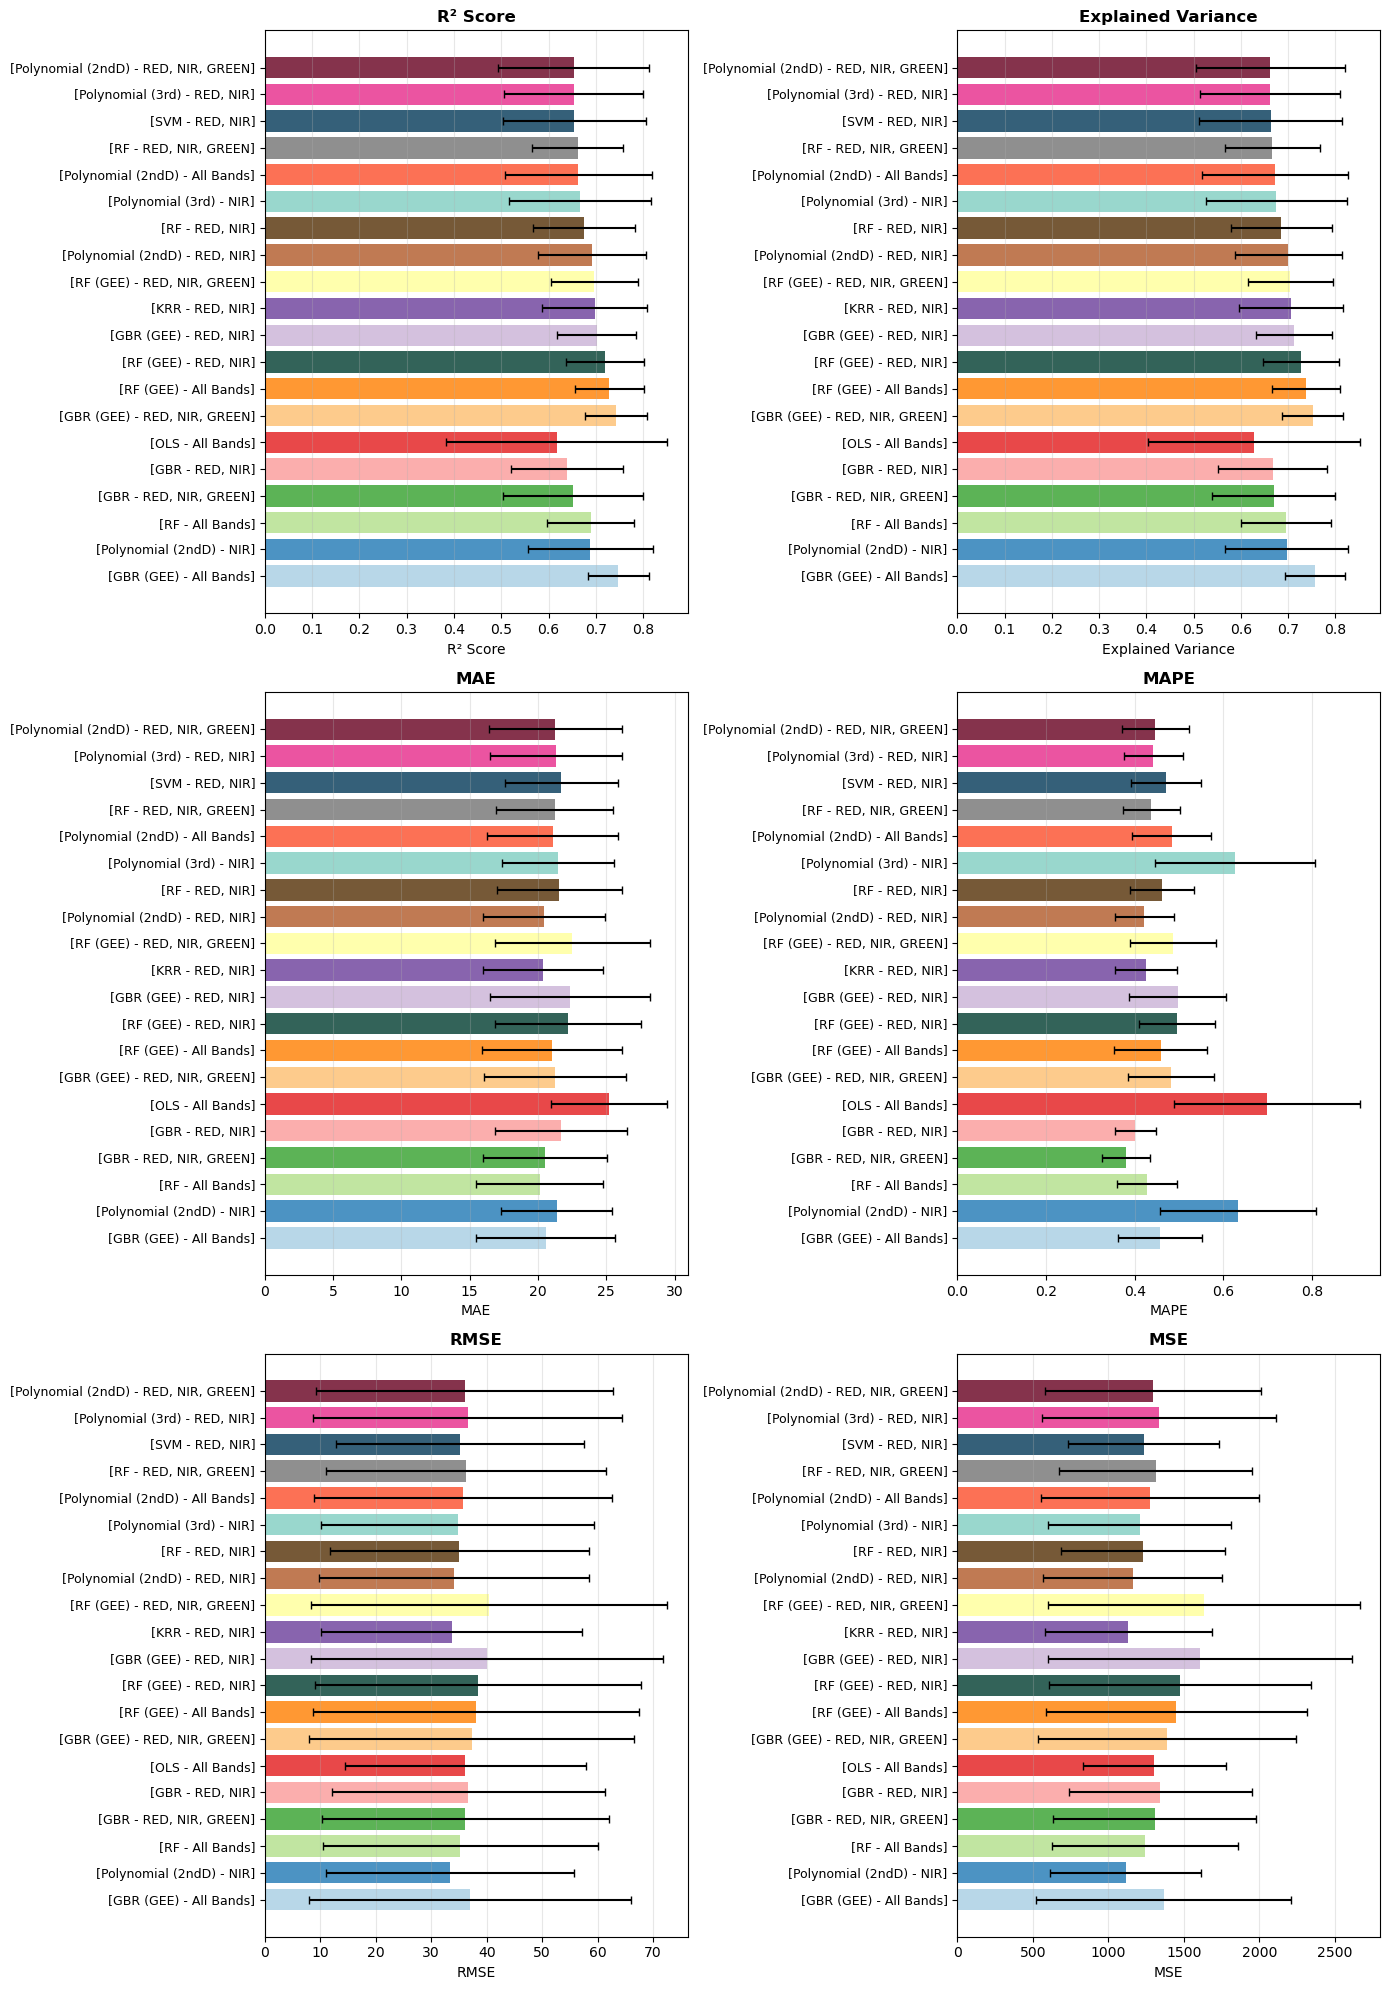

In [92]:
fig, axes = plt.subplots(3, 2, figsize=(14, 20))

metrics = ['r2', 'exp_var', 'mae', 'mape', 'rmse', 'mse']
titles = ['R² Score', 'Explained Variance', 'MAE', 'MAPE', 'RMSE', 'MSE']
color_palette = ['#a6cee3','#1f78b4','#b2df8a','#33a02c','#fb9a99',
                 '#e31a1c','#fdbf6f','#ff7f00','#003c30','#cab2d6',
                 '#6a3d9a','#ffff99','#b15928','#543005','#80cdc1',
                 '#fc4e2a','#737373','#023858','#e7298a','#67001f']

# Create labels combining Model and Feature
models = best_models['Model'].replace({'GBR_GEE':'GBR (GEE)', 'polynomial2': 'Polynomial (2ndD)', 'ols':"OLS", 'RF_GEE': "RF (GEE)", 'polynomial3': 'Polynomial (3rd)'})
features = best_models['Feature'].replace({'all_bands': 'All Bands', 'nir': 'NIR', 'nir_red_green': 'RED, NIR, GREEN', 'nir_red': "RED, NIR"})
labels = [f"[{m} - {f}]" for m, f in zip(models, features)]

# Flatten axes for easier iteration
axes_flat = axes.flatten()
n = 0

for ax, metric, title in zip(axes_flat, metrics, titles):
    if metric in best_models.columns and f'{metric}_std' in best_models.columns:
        # Create horizontal bar plot
        y_pos = np.arange(len(best_models))
        ax.barh(y_pos, best_models[metric], xerr=best_models[f'{metric}_std'], 
                color=color_palette[:len(best_models)], capsize=3, alpha=0.8)
        
        # Set labels and title
        ax.set_yticks(y_pos)
        ax.set_yticklabels(labels, fontsize=9)
        ax.set_xlabel(title, fontsize=10)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.grid(axis='x', alpha=0.3)
    
    n += 1

plt.tight_layout()
plt.savefig(os.path.join(wrk_directory,"metrics_comparison.jpg"),dpi=300)
plt.show()
